In [1]:
from typing import Annotated, TypedDict, List, Dict, Any, Optional
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage
from langchain_openai import ChatOpenAI
from langchain_community.agent_toolkits import PlayWrightBrowserToolkit
from langchain_community.tools.playwright.utils import create_async_playwright_browser
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver
from langgraph.prebuilt import ToolNode
from langgraph.graph.message import add_messages
from pydantic import BaseModel, Field
from IPython.display import Image, display
import gradio as gr
import uuid
from dotenv import load_dotenv
import nest_asyncio
import pandas as pd
import matplotlib.pyplot as plt
import os
import json
import asyncio
import base64 as b64lib, re

In [2]:
load_dotenv(override=True)
nest_asyncio.apply()

In [3]:
class EvaluatorOutput(BaseModel):
    feedback: str = Field(description="Concrete feedback on clarity/length/value")
    isgoodenough: bool = Field(description="True if ready for review")
    toolong: bool = Field(description="True if too dense/Long")
    needsmoredata: bool = Field(description="True if KPIs/charts missing")


In [4]:
class NewsletterState(TypedDict):
    # INPUTS
    period: str
    audience: str
    topics: List[str]                    # e.g. ["AI", "tech", "business"]

    # RAW DATA
    rawmetricsdata: Dict[str, Any]
    metricdeltas: Dict[str, Any]
    productupdatesraw: Dict[str, str]    # now filled by Playwright, not hardcoded

    # PROCESSING
    normalizedupdates: List[Dict[str, Any]]
    insightsections: List[Dict[str, Any]]
    chartspecs: List[Dict[str, Any]]
    chartpaths: List[str]

    # EVALUATION
    layouthtml: str
    editorfeedback: str
    needsvisuals: bool
    isgoodenough: bool
    needsmoredata: bool
    toolong: bool
    loopcount: int

In [5]:
# Initialize LLMs for newsletter system

# 1) Generator model – used for insights, visualization ideas, layout, etc.
generator_llm = ChatOpenAI(model="gpt-4o-mini")

# 2) Evaluator model – same base model, but with structured output schema
evaluator_llm = ChatOpenAI(model="gpt-4o-mini")
evaluatorllm_with_output = evaluator_llm.with_structured_output(EvaluatorOutput)




In [6]:
SOURCE_MAP = {
    "ai":         "https://techcrunch.com/category/artificial-intelligence/",
    "tech":       "https://news.ycombinator.com",
    "business":   "https://www.reuters.com/business/",
    "finance":    "https://www.reuters.com/markets/",
    "world":      "https://www.bbc.com/news/world",
    "science":    "https://www.sciencedaily.com/",
    "startups":   "https://techcrunch.com/startups/",
}

async def fetch_daily_news(state: NewsletterState) -> Dict[str, Any]:
    """
    Playwright node: visits one URL per topic and extracts raw text.
    Populates productupdatesraw so the rest of the pipeline works unchanged.
    """
    topics = state.get("topics", ["tech", "ai", "business"])

    async_browser = create_async_playwright_browser()
    toolkit = PlayWrightBrowserToolkit.from_browser(async_browser=async_browser)
    tools   = {t.name: t for t in toolkit.get_tools()}

    navigate     = tools["navigate_browser"]
    extract_text = tools["extract_text"]

    productupdatesraw = {}

    for topic in topics:
        url = SOURCE_MAP.get(topic.lower(),
              f"https://www.google.com/search?q={topic}+news+today")
        try:
            await navigate.arun({"url": url})
            raw = await extract_text.arun({})
            productupdatesraw[topic] = raw[:4000]      # cap to avoid token overflow
            print(f"  Fetched: {topic} ({len(raw)} chars)")
        except Exception as e:
            productupdatesraw[topic] = f"Could not fetch: {e}"
            print(f"  Failed: {topic} — {e}")

    await async_browser.close()
    return {"productupdatesraw": productupdatesraw}

In [7]:
def normalize_updates(state: NewsletterState) -> Dict[str, Any]:
    """
    LLM node: convert messy productupdatesraw into clean normalized structure.
    """
    system_message = (
        "You are a news editor assistant preparing a daily briefing.\n"
        "- Read raw scraped text from news websites for each topic.\n"
        "- Extract the 2-3 most important stories per topic.\n"
        "- Also extract ALL numeric values mentioned (percentages, counts, prices, rates).\n"
        "- Return ONLY JSON with TWO keys: 'normalized_updates' and 'rawmetricsdata'.\n"
        "- rawmetricsdata format: {\"metric_label\": numeric_value} — flat dict, numbers only.\n"
        "- Do NOT invent numbers not present in the text."
    )
    user_message = f"""
Raw product updates per product (may be long and unstructured):
{state.get('productupdatesraw', {})}

Optional numeric context (rawmetricsdata + metricdeltas):
{{
  "rawmetricsdata": {state.get('rawmetricsdata', {})},
  "metricdeltas": {state.get('metricdeltas', {})}
}}

Return JSON like:
{{
  "normalized_updates": [
    {{
      "product": "<product name from the notes>",
      "area": "<process/domain e.g. O2C, P2P, Backlog Triage>",
      "metrics": {{
        "<metric_name>": <numeric_value_from_text_or_context>,
        "<metric_name_change>": <numeric_delta_if_available>
      }},
      "highlights": [
        "Short highlight about impact and what changed.",
        "Another highlight from the notes."
      ]
    }}
  ]
}}
Do not reuse placeholder values. Infer from actual input.
"""

    resp = generator_llm.invoke(
        [SystemMessage(content=system_message),
         HumanMessage(content=user_message)]
    )

    # existing parse
    try:
        data = json.loads(resp.content)
    except Exception:
        data = {"normalized_updates": [], "rawmetricsdata": {}}

    updates_raw = data.get("normalized_updates", [])
    if isinstance(updates_raw, dict):
        updates = list(updates_raw.values())
    else:
        updates = updates_raw

    raw_metrics = data.get("rawmetricsdata", {})
    # keep only numeric values — guard against LLM returning strings
    raw_metrics = {k: v for k, v in raw_metrics.items() if isinstance(v, (int, float))}

    return {
        "normalizedupdates": updates,
        "rawmetricsdata": raw_metrics,      # ← this is the key addition
    }


In [8]:
def generate_newsletter_draft(state: NewsletterState) -> Dict[str, Any]:
    """
    LLM node: takes normalized updates and returns short section-based draft.
    """
    system_message = (
        "You are a professional daily newsletter writer.\n"
        "Write a concise, engaging morning briefing.\n"
        "- Max 3 sections, one per major topic.\n"
        "- Each section: punchy title + 2-3 bullet points.\n"
        "- Lead with the most important story.\n"
        "- Use plain, direct language — no jargon, no filler.\n"
        "- Include concrete numbers/stats where available.\n"
        "- Return ONLY valid JSON matching the schema."
    )

    normalized = state.get("normalizedupdates", []) 

    user_message = f"""
Current reporting period: {state.get('period', '')}
Target audience: {state.get('audience', '')}

Structured updates (normalized):
{normalized}

Your job:
- Read structured updates.
- Choose most important 2–3 stories for this period.
- Focus on impact, business value, what changed vs. before.
- Group into at most 3 sections.

Return JSON:
{{
  "sections": [
    {{
      "title": "...",
      "product": "Process Intelligence | Process Copilot | ...",
      "bullets": [
        "Short, clear bullet about what happened and why it matters.",
        "Another bullet."
      ]
    }}
  ]
}}
Do not add explanations outside JSON.
"""

    response = generator_llm.invoke(  
        [
            SystemMessage(content=system_message),
            HumanMessage(content=user_message),
        ]
    )

    try:
        draft = json.loads(response.content)
    except Exception:
        draft = {"sections": []}

    sections = draft.get("sections", [])
    
    # FIXED: Use new generic metrics fields
    needs_visuals = True

    loop_count = state.get("loopcount", 0)  #FIX field name

    return {
        "insightsections": sections,  #FIX field name
        "needsvisuals": needs_visuals,  #FIXED field name
        "loopcount": loop_count,  # FIX field name
    }


In [9]:
def route_after_draft(state: NewsletterState) -> str:
    """
    Decide whether to go through chart planning/rendering or straight to evaluation.
    """
    if state.get("needsvisuals", False): 
        return "plancharts"               
    else:
        return "layoutnewsletter" 


In [10]:
def plancharts(state: NewsletterState) -> Dict[str, Any]:
    import re

    system_message = (
        "You are a data visualization expert for a daily news newsletter.\n"
        "STRICT LIMIT: MAX 2-3 charts.\n\n"
        "Chart rules:\n"
        "- 'bar' = category comparisons\n"
        "- 'line' = trends over time (only if 3+ data points)\n"
        "- Always pick the most newsworthy metric\n"
        "Return ONLY valid JSON with a 'charts' key."
    )

    # Always build metrics — use rawmetricsdata if available,
    # otherwise extract numbers from bullet points as fallback
    raw = dict(state.get("rawmetricsdata", {}))

    if not raw:
        sections = state.get("insightsections", [])
        # Fallback 1: story count per topic as a bar chart
        for section in sections:
            label = section.get("product", section.get("title", "Topic"))[:30]
            raw[label] = len(section.get("bullets", []))

        # Fallback 2: extract percentages/numbers from bullets
        for section in sections:
            for bullet in section.get("bullets", []):
                matches = re.findall(r'([\d,.]+)\s*(%|percent|billion|million|thousand|jobs|points)', bullet, re.IGNORECASE)
                for val, unit in matches:
                    clean_val = float(val.replace(",", ""))
                    key = f"{section.get('title','stat')[:20]}_{unit.lower()}"
                    raw[key] = clean_val

    audience_context = f"Audience: {state.get('audience')}\nTailor chart priorities to their needs:\n"

    user_message = f"""
{audience_context}

Available metrics (use EXACT keys):
{json.dumps(raw, indent=2)}

MAX 2-3 charts. Pick the MOST impactful.

Return ONLY valid JSON:
{{
  "charts": [
    {{"id": "topic_breakdown", "title": "Stories by Topic", "type": "bar", "metric": "<exact_key_from_above>"}},
    {{"id": "key_stat", "title": "Key Statistic", "type": "bar", "metric": "<exact_key_from_above>"}}
  ]
}}

Use EXACT metric names from the data above.
"""

    response = generator_llm.invoke([
        SystemMessage(content=system_message),
        HumanMessage(content=user_message)
    ])

    # Also inject raw into state so render_charts can use it
    try:
        data = json.loads(response.content.strip())
        charts_raw = data.get("charts", [])
        charts = charts_raw[:3] if isinstance(charts_raw, list) else []
    except Exception:
        charts = []

    print(f"📊 Planned {len(charts)} charts")
    for c in charts:
        print(f"   {c.get('title')} → {c.get('metric')}")

    return {
        "chartspecs":    charts,
        "needsvisuals":  len(charts) > 0,
        "rawmetricsdata": raw,   # ← update state with fallback metrics too
    }

In [11]:
def render_charts(state: NewsletterState) -> Dict[str, Any]:
    import matplotlib.pyplot as plt
    import matplotlib.ticker as mticker

    print("\n[RENDER_CHARTS] ENTER")

    raw        = state.get("rawmetricsdata", {})
    chart_paths: List[str] = []

    os.makedirs("charts", exist_ok=True)

    # Separate scalars vs series
    scalars = {k: v for k, v in raw.items() if isinstance(v, (int, float))}
    series  = {k: v for k, v in raw.items() if isinstance(v, (list, dict))}

    # ── Chart 1: grouped bar of all scalar metrics ────────────────────────
    if scalars:
        # Clean up labels for display
        labels = [k.replace("_", " ").title() for k in scalars.keys()]
        values = list(scalars.values())

        fig, ax = plt.subplots(figsize=(10, 5))
        bars = ax.barh(labels, values, color="#1F2937", height=0.5)

        # Add value labels inside bars
        for bar, val in zip(bars, values):
            display = f"${val/1e9:.1f}B" if val >= 1e9 else \
                      f"${val/1e6:.1f}M" if val >= 1e6 else \
                      f"{val:,.0f}"
            ax.text(bar.get_width() * 0.02, bar.get_y() + bar.get_height()/2,
                    display, va="center", ha="left",
                    color="white", fontsize=11, fontweight="bold")

        ax.set_xlabel("Value")
        ax.set_title("Key Numbers at a Glance", fontsize=14, fontweight="bold", pad=15)
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(
            lambda x, _: f"${x/1e9:.0f}B" if x >= 1e9 else
                         f"${x/1e6:.0f}M" if x >= 1e6 else
                         f"{x:,.0f}"
        ))
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        plt.tight_layout()

        path = "charts/key_numbers_0.png"
        plt.savefig(path, dpi=150, bbox_inches="tight")
        plt.close()
        chart_paths.append(path)
        print("     saved:", path)

    # ── Chart 2: any time-series data (line chart) ────────────────────────
    for i, (metric, data) in enumerate(series.items()):
        fig, ax = plt.subplots(figsize=(10, 4))

        if isinstance(data, dict):
            x = list(data.keys())
            y = list(data.values())
        else:
            y = list(data)
            x = list(range(len(y)))

        ax.plot(x, y, marker="o", color="#F59E0B", linewidth=2.5, markersize=6)
        ax.fill_between(range(len(y)), y, alpha=0.1, color="#F59E0B")
        ax.set_title(metric.replace("_", " ").title(),
                     fontsize=14, fontweight="bold", pad=15)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        plt.tight_layout()

        path = f"charts/{metric}_{i+1}.png"
        plt.savefig(path, dpi=150, bbox_inches="tight")
        plt.close()
        chart_paths.append(path)
        print("     saved:", path)

    print("  chart_paths final:", chart_paths)
    return {"chartpaths": chart_paths}

In [12]:
def evaluatenewsletterdraft(state: NewsletterState) -> Dict[str, Any]:
    """
    LLM evaluator: checks if draft + layout are ready.
    """

    system_message = (
        "You are a strict editor for a professional daily newsletter.\n"
        "- Must be readable in under 3 minutes.\n"
        "- Max 3 sections, clear titles, 2-3 bullets each.\n"
        "- Reward: specificity, real numbers, crisp writing.\n"
        "- Penalize: vague summaries, repetition, missing key stories.\n"
        "- If layout HTML is present with sections and content, "
        "  set isgoodenough=True unless the writing is genuinely poor.\n"
    )

    user_message = f"""
Period: {state.get('period', '')}
Audience: {state.get('audience', '')}

Draft sections (JSON):
{state.get('insightsections', [])}

Chart specs (title, type, metric):
{state.get('chartspecs', [])}

Rendered chart paths:
{state.get('chartpaths', [])}

Rendered layout HTML (what leadership will actually see):
{state.get('layouthtml', '')}

Evaluate this FULL newsletter (text + visuals) and be specific about:
- What's good
- What needs improvement (length? clarity? missing key metrics? layout issues?)

Set flags accurately:
- isgoodenough=True if this layout + charts are ready for leadership review.
- toolong=True only if it is genuinely too long/dense.
- needsmoredata=True only if important metrics/visuals are missing AND the current charts/layout are not enough to understand progress.

"- If chartpaths is non-empty AND layouthtml clearly embeds these charts, "
"  you should usually set isgoodenough=True unless the text is extremely unclear or far too long."
"""

    eval_result = evaluatorllm_with_output.invoke(
        [
            SystemMessage(content=system_message),
            HumanMessage(content=user_message),
        ]
    )

    loopcount = state.get("loopcount", 0) + 1

    return {
        "editorfeedback": eval_result.feedback,
        "isgoodenough": eval_result.isgoodenough,
        "needsmoredata": eval_result.needsmoredata,
        "toolong": eval_result.toolong,
        "loopcount": loopcount,
    }


In [13]:
def routebasedonevaluation(state: NewsletterState) -> str:
    """
    After evaluation: loop back to draft OR end.
    Stops at 3 loops OR when good enough.
    """
    loopcount = state.get("loopcount", 0)
    isgoodenough = state.get("isgoodenough", False)
    
    if isgoodenough or loopcount >= 3: 
        return "END"
    else:
        return "generatenewsletterdraft" 


In [14]:
def layout_newsletter(state: NewsletterState) -> Dict[str, Any]:
    """
    LLM node: Intelligently plans chart-section matching and layout.
    """
    import base64 as b64lib
    import re

    system_message = """
You are a professional daily newsletter layout expert.

RULES:
- Use h2 for section titles, NOT h1
- Use .product-tag for topic/category labels
- Use ul/li for bullet points
- If charts are available, place them inside .chart-container divs
- img tags must use src="CHART_PATH_HERE" as placeholder
- Output ONLY raw HTML — no markdown, no code fences, no explanation
- Do NOT include <html>, <head>, <body> tags
"""

    user_message = f"""
Period: {state.get('period')}
Audience: {state.get('audience')}

SECTIONS ({len(state.get('insightsections', []))}):
{json.dumps(state.get('insightsections', []), indent=2)}

CHARTS ({len(state.get('chartspecs', []))}):
{json.dumps(state.get('chartspecs', []), indent=2)}
Paths: {state.get('chartpaths', [])}

CSS classes available:
- h2 for section titles
- .product-tag for topic labels
- ul/li for bullets
- .chart-container + .chart-title for charts
- img src="CHART_PATH_HERE" as placeholder (one per chart, in order)

RULES:
- Use h2 for section titles, NOT h1
- Use .product-tag for topic/category labels
- Use ul/li for bullet points
- If charts are available, place them inside .chart-container divs
- img tags must use src="CHART_PATH_HERE" as placeholder
- Output ONLY raw HTML — no markdown, no code fences, no explanation
- Do NOT include <html>, <head>, <body> tags

STRICT CHART RULES:
- Each chart must appear EXACTLY ONCE in the entire output
- Do NOT create a "Key Metrics" section at the end
- Do NOT repeat a chart that was already placed inside a section
- Place each chart next to its most relevant section only
- If no section matches a chart, place it once at the very end, not in a separate repeated block
"""

    response = generator_llm.invoke([
        SystemMessage(content=system_message),
        HumanMessage(content=user_message)
    ])

    # Strip markdown code fences if LLM wraps output
   

    content = response.content.strip()
    if content.startswith("```html"):
        content = content[7:]
    elif content.startswith("```"):
        content = content[3:]
    if content.endswith("```"):
        content = content[:-3]
    content = content.strip()

    # Replace ANY img src (file path or placeholder) with base64
    chart_paths = state.get("chartpaths", [])
    for path in chart_paths:
        if os.path.exists(path):
            with open(path, "rb") as f:
                encoded = b64lib.b64encode(f.read()).decode()
            b64_src = f"data:image/png;base64,{encoded}"
            # Replace both placeholder and direct file path references
            content = re.sub(
                r'src=["\']([^"\']*' + re.escape(os.path.basename(path)) + r')["\']',
                f'src="{b64_src}"',
                content
            )
            content = content.replace("CHART_PATH_HERE", b64_src, 1)

    # Remove any remaining unresolved chart containers
    content = re.sub(
        r'<div class="chart-container">.*?CHART_PATH_HERE.*?</div>',
        '', content, flags=re.DOTALL
    )

    print(f"Layout ready with {len(chart_paths)} embedded charts")
    return {"layouthtml": content}

In [15]:
graph_builder = StateGraph(NewsletterState)

graph_builder.add_node("fetchdailynews",          fetch_daily_news)
graph_builder.add_node("normalizeupdates",         normalize_updates)
graph_builder.add_node("generatenewsletterdraft",  generate_newsletter_draft)
graph_builder.add_node("plancharts",               plancharts)
graph_builder.add_node("rendercharts",             render_charts)
graph_builder.add_node("layoutnewsletter",         layout_newsletter)
graph_builder.add_node("evaluatenewsletterdraft",  evaluatenewsletterdraft)

graph_builder.add_edge(START,              "fetchdailynews")
graph_builder.add_edge("fetchdailynews",   "normalizeupdates")
graph_builder.add_edge("normalizeupdates", "generatenewsletterdraft")

graph_builder.add_conditional_edges(
    "generatenewsletterdraft",
    route_after_draft,
    {
        "plancharts":      "plancharts",
        "layoutnewsletter": "layoutnewsletter",
    },
)

graph_builder.add_edge("plancharts",    "rendercharts")
graph_builder.add_edge("rendercharts",  "layoutnewsletter")
graph_builder.add_edge("layoutnewsletter", "evaluatenewsletterdraft")

graph_builder.add_conditional_edges(
    "evaluatenewsletterdraft",
    routebasedonevaluation,
    {
        "generatenewsletterdraft": "generatenewsletterdraft",
        "END": END,
    },
)

app = graph_builder.compile()
print("GRAPH BUILT SUCCESSFULLY!")

GRAPH BUILT SUCCESSFULLY!


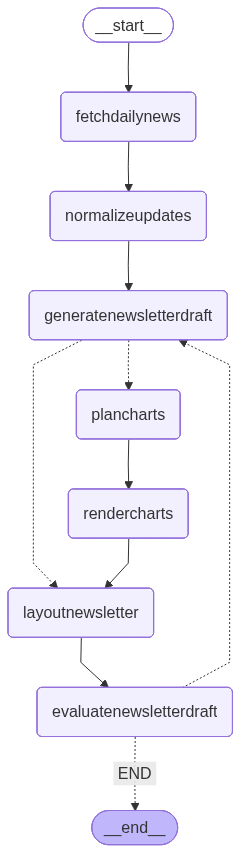

In [16]:
display(Image(app.get_graph().draw_mermaid_png()))

In [17]:
from datetime import date

initial_state: NewsletterState = {
    "period":   f"Daily Briefing — {date.today().strftime('%A, %B %d %Y')}",
    "audience": "General Professional",
    "topics":   ["ai", "tech", "business"],    # change these to whatever you want

    # Playwright fills this — leave empty
    "productupdatesraw": {},
    "rawmetricsdata":    {},
    "metricdeltas":      {},

    # Pipeline fills these
    "normalizedupdates": [],
    "insightsections":   [],
    "chartspecs":        [],
    "chartpaths":        [],
    "layouthtml":        "",
    "editorfeedback":    "",

    # Flags
    "needsvisuals":   False,
    "isgoodenough":   False,
    "needsmoredata":  False,
    "toolong":        False,
    "loopcount":      0,
}

In [19]:
def run_newsletter(period, audience, topics_str):
    state = initial_state.copy()
    state["period"]   = period
    state["audience"] = audience
    state["topics"]   = [t.strip() for t in topics_str.split(",")]

    result = asyncio.run(app.ainvoke(state))

    html_content = f"""
<!DOCTYPE html>
<html>
<head>
    <meta charset="UTF-8">
    <title>Daily Briefing - {result.get('period', '')}</title>
    <link href="https://fonts.googleapis.com/css2?family=Inter:wght@300;400;500;600;700&display=swap" rel="stylesheet">
    <style>
        * {{ margin: 0; padding: 0; box-sizing: border-box; }}
        body {{ font-family: 'Inter', sans-serif; line-height: 1.6; color: #1F2937; background: linear-gradient(135deg, #F8FAFC 0%, #E2E8F0 100%); padding: 40px 20px; min-height: 100vh; }}
        .container {{ max-width: 900px; margin: 0 auto; background: white; border-radius: 16px; box-shadow: 0 20px 60px rgba(0,0,0,0.1); overflow: hidden; }}
        .header {{ background: linear-gradient(135deg, #1F2937 0%, #111827 100%); color: white; padding: 40px; text-align: center; }}
        .logo {{ font-size: 36px; font-weight: 700; margin-bottom: 8px; letter-spacing: 2px; }}
        .tagline {{ font-size: 18px; font-weight: 300; opacity: 0.95; margin-bottom: 24px; letter-spacing: 1px; }}
        .period {{ font-size: 28px; font-weight: 600; margin-bottom: 12px; }}
        .audience {{ font-size: 16px; opacity: 0.9; }}

        /* ── Content area — force dark text always ── */
        .content {{ padding: 50px 60px 60px; background: white; color: #1F2937 !important; }}
        .content * {{ color: #1F2937 !important; background: none !important; }}
        .content p,
        .content span,
        .content div,
        .content li,
        .content h1,
        .content h2,
        .content h3 {{ color: #1F2937 !important; }}

        /* Exceptions */
        .content .product-tag {{ color: white !important; background: linear-gradient(135deg, #1F2937, #374151) !important; }}
        .content .chart-container {{ background: #F8FAFC !important; }}

        h2 {{ font-size: 24px; font-weight: 600; color: #111827 !important; margin: 40px 0 20px 0; padding-bottom: 8px; border-bottom: 2px solid #F3F4F6; position: relative; }}
        h2::after {{ content: ''; position: absolute; bottom: -2px; left: 0; width: 60px; height: 3px; background: linear-gradient(90deg, #F59E0B, #EF4444); border-radius: 2px; }}
        .product-tag {{ background: linear-gradient(135deg, #1F2937, #374151) !important; color: white !important; padding: 6px 16px; border-radius: 20px; font-size: 14px; font-weight: 500; display: inline-block; margin-bottom: 20px; text-transform: uppercase; letter-spacing: 0.5px; }}
        ul {{ list-style: none; padding-left: 0; margin: 24px 0; }}
        li {{ margin: 20px 0; padding-left: 32px; position: relative; font-size: 16px; color: #1F2937 !important; }}
        li::before {{ content: "→"; position: absolute; left: 0; top: 2px; color: #F59E0B !important; font-weight: 700; font-size: 20px; }}
        .chart-container {{ background: #F8FAFC !important; border: 1px solid #E2E8F0; border-radius: 12px; padding: 24px; margin: 32px 0; }}
        .chart-title {{ font-size: 18px; font-weight: 600; color: #1F2937 !important; margin-bottom: 16px; }}
        img {{ max-width: 100%; height: auto; border-radius: 8px; box-shadow: 0 8px 32px rgba(0,0,0,0.12); }}
        .footer {{ background: #111827 !important; color: white !important; text-align: center; padding: 32px 60px; font-size: 14px; }}
        .footer * {{ color: white !important; }}
    </style>
</head>
<body>
    <div class="container">
        <div class="header">
            <div class="logo">THE DAILY BRIEF</div>
            <div class="tagline">Your Morning Intelligence</div>
            <div class="period">{result.get('period', '')}</div>
            <div class="audience">{result.get('audience', '')}</div>
        </div>
        <div class="content">
            {result.get('layouthtml', '')}
        </div>
        <div class="footer">
            <p>Daily Briefing | {result.get('period', '')} | Auto-generated</p>
        </div>
    </div>
</body>
</html>
"""

    output_path = os.path.join(os.getcwd(), "newsletter.html")
    with open(output_path, "w", encoding="utf-8") as f:
        f.write(html_content)

    return (
        result.get("insightsections", []),
        result.get("editorfeedback", ""),
        result.get("chartpaths", []),
        html_content,
        output_path,
    )


with gr.Blocks() as demo:
    gr.Markdown("## 🗞️ The Daily Brief — Newsletter Generator")

    with gr.Row():
        period    = gr.Textbox(label="Period",   value="Daily Briefing — Monday, June 15 2026")
        audience  = gr.Textbox(label="Audience", value="General Professional")

    topics_in = gr.Textbox(
        label="Topics (comma-separated)",
        value="ai, tech, business"
    )

    run_btn = gr.Button("Generate Newsletter", variant="primary")

    with gr.Tabs():
        with gr.Tab("📰 Preview"):
            html_out = gr.HTML(label="Newsletter Preview")
        with gr.Tab("📋 Sections"):
            sections_out = gr.JSON(label="Draft Sections")
        with gr.Tab("✏️ Editor Feedback"):
            feedback_out = gr.Textbox(label="Editor Feedback", lines=6)
        with gr.Tab("📊 Charts"):
            charts_out = gr.JSON(label="Chart Paths")
        with gr.Tab("💾 Download"):
            file_out = gr.File(label="Download newsletter.html")

    run_btn.click(
        run_newsletter,
        [period, audience, topics_in],
        [sections_out, feedback_out, charts_out, html_out, file_out],
    )

demo.launch(share=True)

* Running on local URL:  http://127.0.0.1:7861
* Running on public URL: https://341d77026e5f5f65b5.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
